# Energy Consumption Forecasting using Deep Learning

## Project Overview

This project aims to forecast household energy consumption using Deep Learning techniques, specifically Long Short-Term Memory (LSTM) networks.

The project follows a complete Machine Learning pipeline including:

- Data Understanding
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Time Series Forecasting using LSTM
- Model Evaluation
- Model Comparison
- Dashboard Visualization

Dataset:
Individual Household Electric Power Consumption Dataset

## Section 2:Import Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

## Section 3: Load Dataset

In [32]:
df = pd.read_csv(
    'household_power_consumption.txt',
    sep=";",
    low_memory= False
)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


## Section 4: Dataset Shape

In [33]:
print("Dataset Shape : ", df.shape)

Dataset Shape :  (2075259, 9)


## Section 5: Data Information

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


## Section 6: Missing Values

In [35]:
missing = df.isnull().sum()

print ("Sum of missing values:", missing)

Sum of missing values: Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


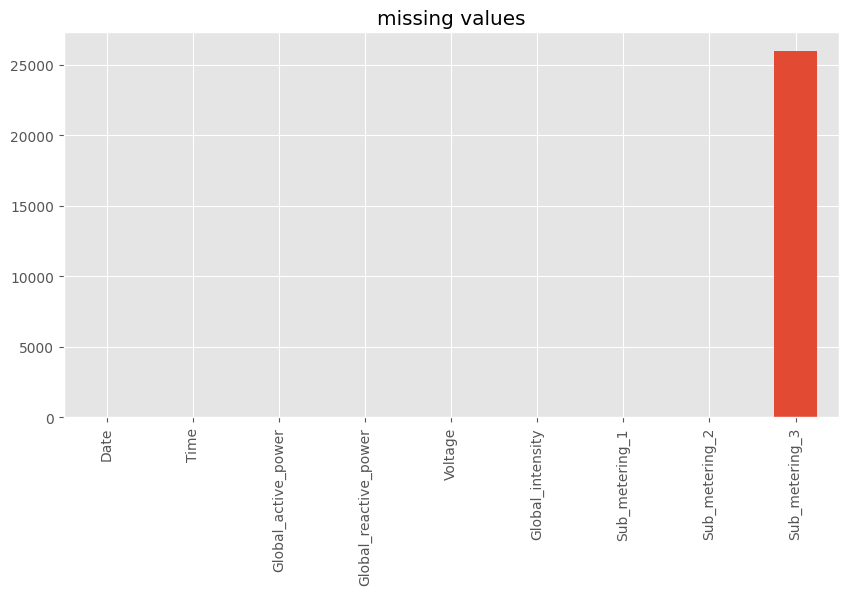

In [36]:
plt.figure(figsize=(10,5))

missing.plot(kind='bar')

plt.title("missing values")

plt.show()

## Section 7: Convert Missing Values

In [37]:
df.replace("?" , np.nan, inplace= True)

In [38]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

## Section 8: Convert Data Types

In [39]:
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

df[numeric_columns] = df[numeric_columns].astype(float)

## Section 9: Create Datetime Column

In [40]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


## Section 10: Check Datetime

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   object        
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   Datetime               datetime64[ns]
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 158.3+ MB


## Section 11: Set Datetime Index

In [42]:
df.set_index("Datetime", inplace=True)
df.drop(columns=["Date", "Time"], inplace=True)

## Section 12: Daily Aggregation

In [43]:
daily_data = df.resample("D").mean()

## Section 13: Daily Dataset

In [44]:
daily_data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


## Section 14: Statistical Summary

In [45]:
daily_data.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000,1433.000000
mean,1.092048,0.123816,240.836421,4.629728,1.123143,1.298620,6.444100
std,0.420415,0.034131,2.045493,1.741352,1.113913,1.461039,2.568978
min,0.173818,0.057811,231.088229,0.808333,0.000000,0.000000,0.000000
25%,0.816776,0.099188,240.094778,3.503333,0.440972,0.299306,4.638889
50%,1.080732,0.119092,240.965688,4.556111,0.775694,0.479167,6.447222
75%,1.323926,0.141454,241.878583,5.540556,1.545139,1.897222,8.155556
max,3.314851,0.290162,247.435007,14.028056,7.767894,8.409028,16.488194


## Section 15: Correlation Matrix

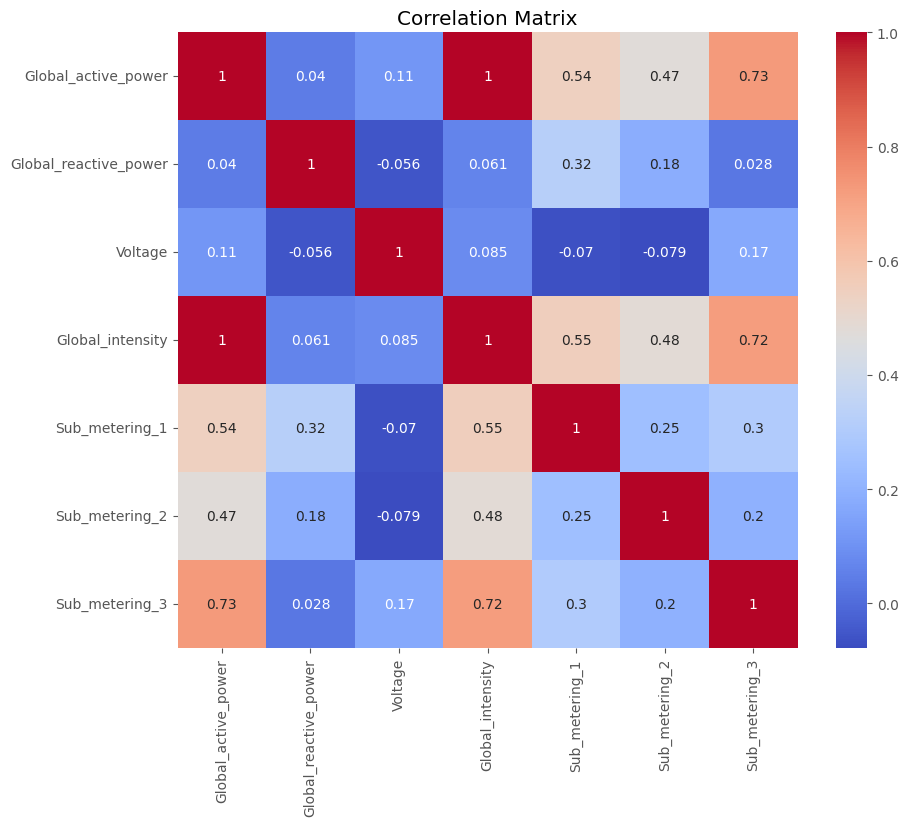

In [46]:
plt.figure(figsize=(10,8))

sns.heatmap(
    daily_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Section 16: Daily Power Plot

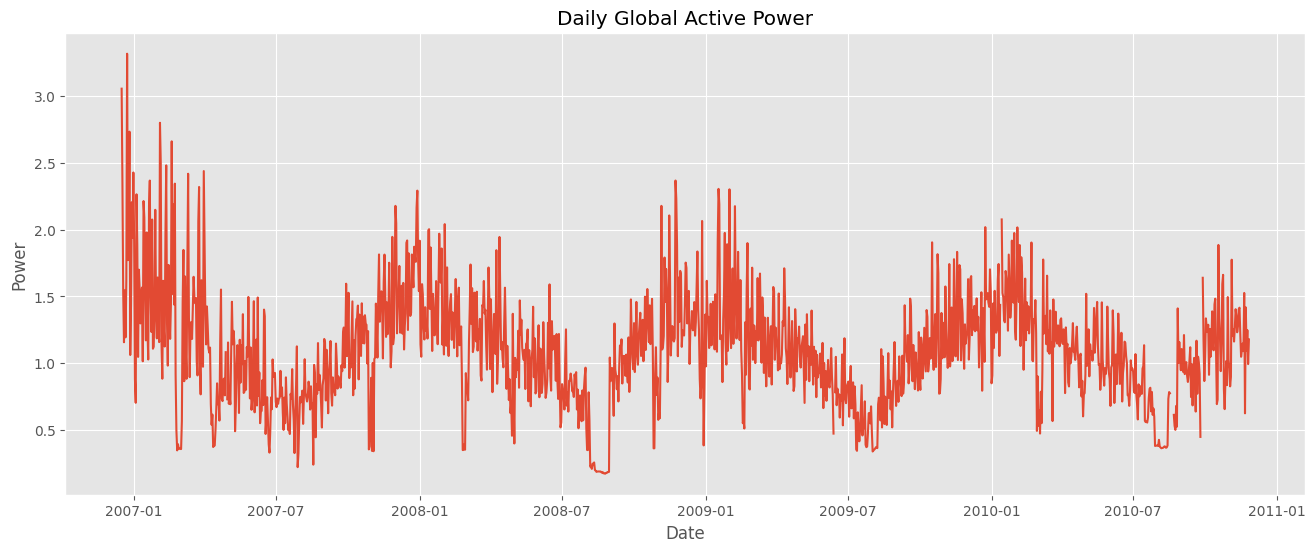

In [47]:
plt.figure(figsize=(16,6))

plt.plot(
    daily_data["Global_active_power"]
)

plt.title("Daily Global Active Power")

plt.xlabel("Date")

plt.ylabel("Power")

plt.show()

## Section 17: Distribution

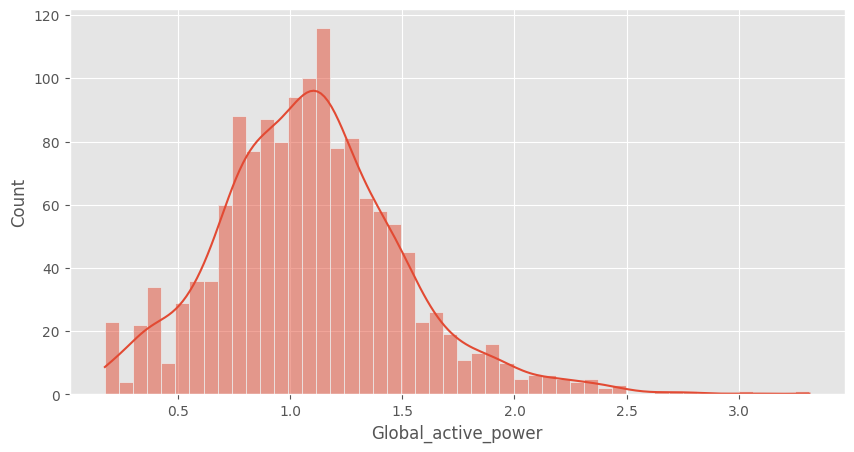

In [48]:
plt.figure(figsize=(10,5))

sns.histplot(
    daily_data["Global_active_power"],
    bins=50,
    kde=True
)

plt.show()

## Section 18: Box Plot

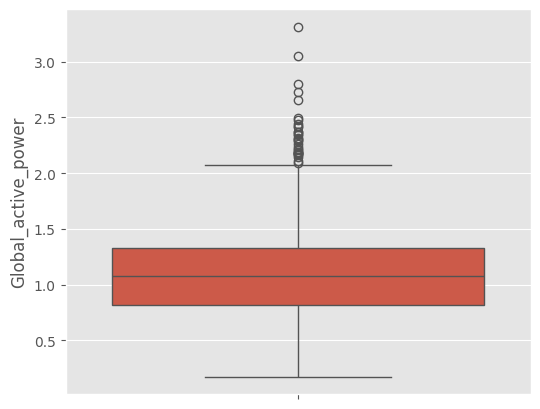

In [49]:
plt.figure(figsize=(6,5))

sns.boxplot(
    y=daily_data["Global_active_power"]
)

plt.show()

## Section 19: Save Clean Dataset

In [50]:
daily_data.to_csv("daily_energy_data.csv")